# Temporal Sentiment Analysis of Nuclear/Atomic Energy Discourse

This notebook executes the complete temporal analysis pipeline for Chapter 10, analyzing sentiment trends over time and across article categories.

**Pipeline Overview**:
1. Filter and categorize articles by topic (Energy vs. Weapons)
2. Extract nuclear/atomic context snippets from main articles
3. Run RoBERTa-Twitter sentiment analysis on full corpus
4. Merge sentiment scores with temporal and categorical metadata
5. Visualize temporal trends (yearly and quarterly)
6. Analyze sentiment distribution by article category

## Setup: Import Required Libraries

In [2]:
import os
import pandas as pd

# Set working directory to kapitel_10 for script execution
os.chdir('kapitel_9')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\janal\OneDrive\Desktop\kapitel_9\kapitel_9


## Step 1: Filter and Categorize Articles by Topic

This step categorizes articles based on their subject metadata, focusing on articles where nuclear/atomic topics are **main subjects** (first three subjects).

**What it does**:
- Examines the first three subjects of each article
- Classifies articles into categories:
  - **W** (Weapons) - Nuclear weapons-related topics dominate
  - **E** (Energy) - Energy-related topics dominate  
  - **SPLIT** - Both W and E appear with equal weight
  - **IRR** (Irrelevant) - Neither W nor E in first three subjects (dropped from analysis)
- Uses keyword matching and percentage scores from subject metadata

**Classification Rules**:
1. If only W or E appears → that category
2. If multiple subjects are W (or E) → that category
3. If both W and E present → category with highest percentage wins; if tied → SPLIT

**Output**: `main_topic.csv` (categorized articles with W/E/SPLIT labels)

In [3]:
print("Filtering and categorizing articles by main topic...\n")
%run filter_main_only.py

Filtering and categorizing articles by main topic...

Saved 3976 categorised articles to 'main_topic.csv'.


### Verify Categorization

Check the distribution of articles across categories:

In [4]:
# Load categorized articles
if os.path.exists('main_topic.csv'):
    main_df = pd.read_csv('main_topic.csv', sep=';', encoding='utf-8')
    print(f"Total articles in main_topic.csv: {len(main_df)}\n")
    print("Category distribution:")
    print(main_df['Category'].value_counts())
    print("\nFirst 5 articles:")
    print(main_df[['ID', 'Category', 'Datum_standardisiert', 'Subject']].head())
else:
    print("main_topic.csv not found!")

Total articles in main_topic.csv: 3976

Category distribution:
Category
W        2703
E        1175
SPLIT      98
Name: count, dtype: int64

First 5 articles:
     ID Category Datum_standardisiert  \
0     7        W           1984-08-15   
1  8217        W           2005-11-13   
2  8218        W           2008-09-23   
3  8227        W           1996-06-26   
4  8230        W           1989-01-23   

                                             Subject  
0  LETTERS & COMMENTS (90%); NUCLEAR WEAPONS (90%...  
1  MILITARY WEAPONS (90%); NUCLEAR WEAPONS (90%);...  
2  INTERNATIONAL RELATIONS (90%); NUCLEAR WEAPONS...  
3  BOMBS & EXPLOSIVE DEVICES (91%); MILITARY WEAP...  
4  MILITARY WEAPONS (90%); NUCLEAR WEAPONS (90%);...  


## Step 2: Extract Context Snippets from Main Articles

Extract sentences containing "nuclear" or "atom" keywords along with ±1 sentence of context from the categorized articles. Note that this script is not the same as the one used in Kapitel 9 since the input CSV is different.

**What it does**:
- Uses NLTK sentence tokenization
- Regex pattern: `\b(nuclear|atom\w*)\b` (case-insensitive)
- Extracts ±1 sentence window around each keyword match
- Merges overlapping context windows
- Removes duplicate context blocks

**Output**: `snippets_main.csv` (extracted contexts with column `all_snippets`)

In [5]:
print("Extracting nuclear/atomic context snippets...\n")
%run sentence_context.py main_topic.csv

Extracting nuclear/atomic context snippets...



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\janal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\janal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Reading articles from: main_topic.csv
→ Grouped output saved with 3975 articles and columns ['ID', 'Datum_standardisiert', 'category', 'all_snippets'].


### Verify Context Extraction

Check the extracted snippets:

In [6]:
if os.path.exists('snippets_main.csv'):
    snippets_df = pd.read_csv('snippets_main.csv', sep=';', encoding='utf-8')
    print(f"Total context snippets extracted: {len(snippets_df)}\n")
    print("Columns:", list(snippets_df.columns))
    print("\nFirst snippet example:")
    print(snippets_df.iloc[0]['all_snippets'][:300] + "...")
else:
    print("snippets_main.csv not found!")

Total context snippets extracted: 3975

Columns: ['ID', 'Datum_standardisiert', 'category', 'all_snippets']

First snippet example:
$50 MILLION QUESTION

To the Editor:
 Your Aug. 5 news article ''U.S. Weighs Risk That Atom War Could Bring Fatal Nuclear Winter'' made me wonder who would spend $50 million to discover if a nuclear war would exterminate some, most or all life in a cloud of dust that blots out the sun. It is clear t...


## Step 3: RoBERTa-Twitter Sentiment Analysis

Run sentiment analysis on the full corpus using the RoBERTa-Twitter model (`cardiffnlp/twitter-roberta-base-sentiment-latest`).

**Prerequisites**:
- Requires PyTorch to be installed
- For CPU-only: `pip install torch --index-url https://download.pytorch.org/whl/cpu`
- For GPU support (faster): `pip install torch`
- Note: Jupyter kernel will need to be restarted after PyTorch installation

**What it does**:
- Tokenizes text into sentences using NLTK
- Scores each sentence with RoBERTa-Twitter (batch_size=16)
- Returns probabilities for positive/negative classes
- Aggregates sentence scores to document-level polarity: `(Σp_pos - Σp_neg) / (Σp_pos + Σp_neg)`
- Saves checkpoints every 5000 sentences for interruption recovery
- Auto-detects CUDA availability for GPU acceleration

**Outputs**: 
- `sentence_sentiment_main.csv` (sentence-level scores with doc_id, sentence text, p_positive, p_negative)
- `polarity_results_main.csv` (document-level polarity aggregation)
- `RoBERTa_Twitter_Polarity_main.png` (histogram of polarity distribution)

**Note**: This step may take considerable time depending on corpus size and hardware (CPU vs GPU).

In [7]:
print("Running RoBERTa-Twitter sentiment analysis on full corpus...\n")
print("This may take a while depending on corpus size and hardware.\n")
%run roberta_alpha_polarity.py

Running RoBERTa-Twitter sentiment analysis on full corpus...

This may take a while depending on corpus size and hardware.



c:\Users\janal\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading CSV…
CSV loaded. Columns: ['ID', 'Datum_standardisiert', 'category', 'all_snippets']
Loading model…


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
c:\Users\janal\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` o

Model ready. Labels: {'negative': 0, 'neutral': 1, 'positive': 2}
Scoring sentences…


Documents:   1%|          | 28/3975 [02:33<6:00:06,  5.47s/it] 


 Interrupted by user. Saving partial results…


SystemExit: 1

### Verify Sentiment Analysis Results

Check the sentiment scoring outputs:

In [8]:
files_to_check = ['sentence_sentiment_main.csv', 'polarity_results_main.csv']

for file in files_to_check:
    if os.path.exists(file):
        df = pd.read_csv(file)
        print(f"\n{file}: {len(df)} rows")
        print("Columns:", list(df.columns))
        if file == 'polarity_results_main.csv':
            print(f"\nPolarity statistics:")
            print(f"  Mean:   {df['polarity'].mean():+.3f}")
            print(f"  Median: {df['polarity'].median():+.3f}")
            print(f"  Std:    {df['polarity'].std():.3f}")
            print(f"  Min:    {df['polarity'].min():+.3f}")
            print(f"  Max:    {df['polarity'].max():+.3f}")
    else:
        print(f"\n{file}: NOT FOUND")


sentence_sentiment_main.csv: 87087 rows
Columns: ['doc_id', 'sentence', 'p_positive', 'p_negative', 'sentence_polarity']

polarity_results_main.csv: 3975 rows
Columns: ['doc_id', 'p_positive', 'p_negative', 'polarity']

Polarity statistics:
  Mean:   -0.491
  Median: -0.603
  Std:    0.376
  Min:    -0.971
  Max:    +0.984


## Step 4: Merge Sentiment with Metadata

Combine sentiment results with temporal (date) and categorical (W/E/SPLIT) metadata for analysis.

**Output**: `sentence_sentiment_with_meta.csv` (unified dataset with sentiment + metadata)

In [9]:
print("Merging sentiment results with temporal and categorical metadata...\n")
%run merge_sentiment_date_category.py

Merging sentiment results with temporal and categorical metadata...

Merge complete. File saved as sentence_sentiment_with_meta.csv
   ID  p_positive  p_negative  polarity Datum_standardisiert Category
0   7    0.260826    3.770549 -0.870602           1984-08-15        W
1   8    4.258306    1.130557  0.580410           2006-09-20        W
2  11    2.465297    8.087462 -0.532767           2015-12-23        W
3  12    2.242495   16.451474 -0.760084           1985-10-20        W
4  20    0.393577    2.337209 -0.711748           1982-10-08        W


### Preview Merged Dataset

Examine the merged dataset with all metadata:

In [10]:
if os.path.exists('sentence_sentiment_with_meta.csv'):
    meta_df = pd.read_csv('sentence_sentiment_with_meta.csv')
    print(f"Merged dataset: {len(meta_df)} documents\n")
    print("Columns:", list(meta_df.columns))
    print("\nFirst 5 rows:")
    print(meta_df[['ID', 'polarity', 'Category', 'Datum_standardisiert']].head())
    print("\nCategory breakdown:")
    print(meta_df['Category'].value_counts())
else:
    print("sentence_sentiment_with_meta.csv not found!")

Merged dataset: 3975 documents

Columns: ['ID', 'p_positive', 'p_negative', 'polarity', 'Datum_standardisiert', 'Category']

First 5 rows:
   ID  polarity Category Datum_standardisiert
0   7 -0.870602        W           1984-08-15
1   8  0.580410        W           2006-09-20
2  11 -0.532767        W           2015-12-23
3  12 -0.760084        W           1985-10-20
4  20 -0.711748        W           1982-10-08

Category breakdown:
Category
W        2703
E        1174
SPLIT      98
Name: count, dtype: int64


## Step 5: Explore Data Distributions

Generate summary statistics about the corpus distribution over time and topics.

### Count Articles per Year and Category

**What it does**:
- Parses dates from `Datum_standardisiert` column
- Groups articles by year and category (W/E/SPLIT)
- Generates two output formats:
  - Pivot table (years as rows, categories as columns)
  - Long format (year-category-count triplets)

**Outputs**:
- `articles_per_year_category.csv` (pivot table format)
- `articles_per_year_category_long.csv` (long format for plotting)

In [11]:
print("Counting articles per year and category...\n")
%run count_articles_year.py

Counting articles per year and category...

Articles per Year x Category (pivot):
Category   E  SPLIT   W
Year                   
2010       7      1  72
2011      30      2  38
2012      18      2  83
2013      12      3  53
2014      13      1  43
2015      14      1  58
2016       2      0  45
2017      17      0  61
2018       5      0  75
2019       6      0  28
2020       3      0  42
2021       4      0  40
2022      36      1  44
2023      10      0  52
2024      14      0  53

Saved wide table -> articles_per_year_category.csv
Saved long table  -> articles_per_year_category_long.csv


C:\Users\janal\OneDrive\Desktop\kapitel_9\kapitel_9\count_articles_year.py:18: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["__parsed_date"] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")


### Explore Main Topics Distribution

**What it does**:
- Counts articles per year across the entire dataset
- Analyzes topic distribution from subject metadata
- Provides overview of corpus temporal and thematic coverage

In [12]:
print("Exploring topic distributions...\n")
%run explore_main_topics.py

Exploring topic distributions...


Articles per Year:
year
1980.0     68
1981.0    183
1982.0    192
1983.0    120
1984.0    113
1985.0    103
1986.0    104
1987.0     83
1988.0    118
1989.0    100
1990.0     79
1991.0    122
1992.0    105
1993.0     69
1994.0    130
1995.0     92
1996.0     32
1997.0     54
1998.0     66
1999.0     55
2000.0     36
2001.0     44
2002.0     86
2003.0    137
2004.0    166
2005.0    112
2006.0    136
2007.0    117
2008.0     66
2009.0     79
2010.0     80
2011.0     70
2012.0    103
2013.0     68
2014.0     57
2015.0     73
2016.0     47
2017.0     78
2018.0     80
2019.0     34
2020.0     45
2021.0     44
2022.0     81
2023.0     62
2024.0     67
Name: count, dtype: int64

Articles per Topic:
Subject
NUCLEAR WEAPONS (90%)                     2830
WEAPONS & ARMS (90%)                      1168
WEAPONS & ARMS (89%)                       792
MILITARY WEAPONS (89%)                     595
ENERGY DEPARTMENTS (90%)                   578
                     

## Step 6: Visualize Temporal Sentiment Trends

Create visualizations showing how sentiment towards nuclear/atomic topics evolved over time.

### Yearly Sentiment Trends (1980-2024)

**What it does**:
- Calculates average sentiment per year for each category (E vs W)
- Creates side-by-side bar chart comparing Energy and Weapons sentiment yearly
- Covers period from 1980 to 2024
- Missing years appear as gaps (no bars)

**Output**: `sentiment_main_yearly.png` (bar chart with E and W categories)

Generating yearly sentiment visualization...



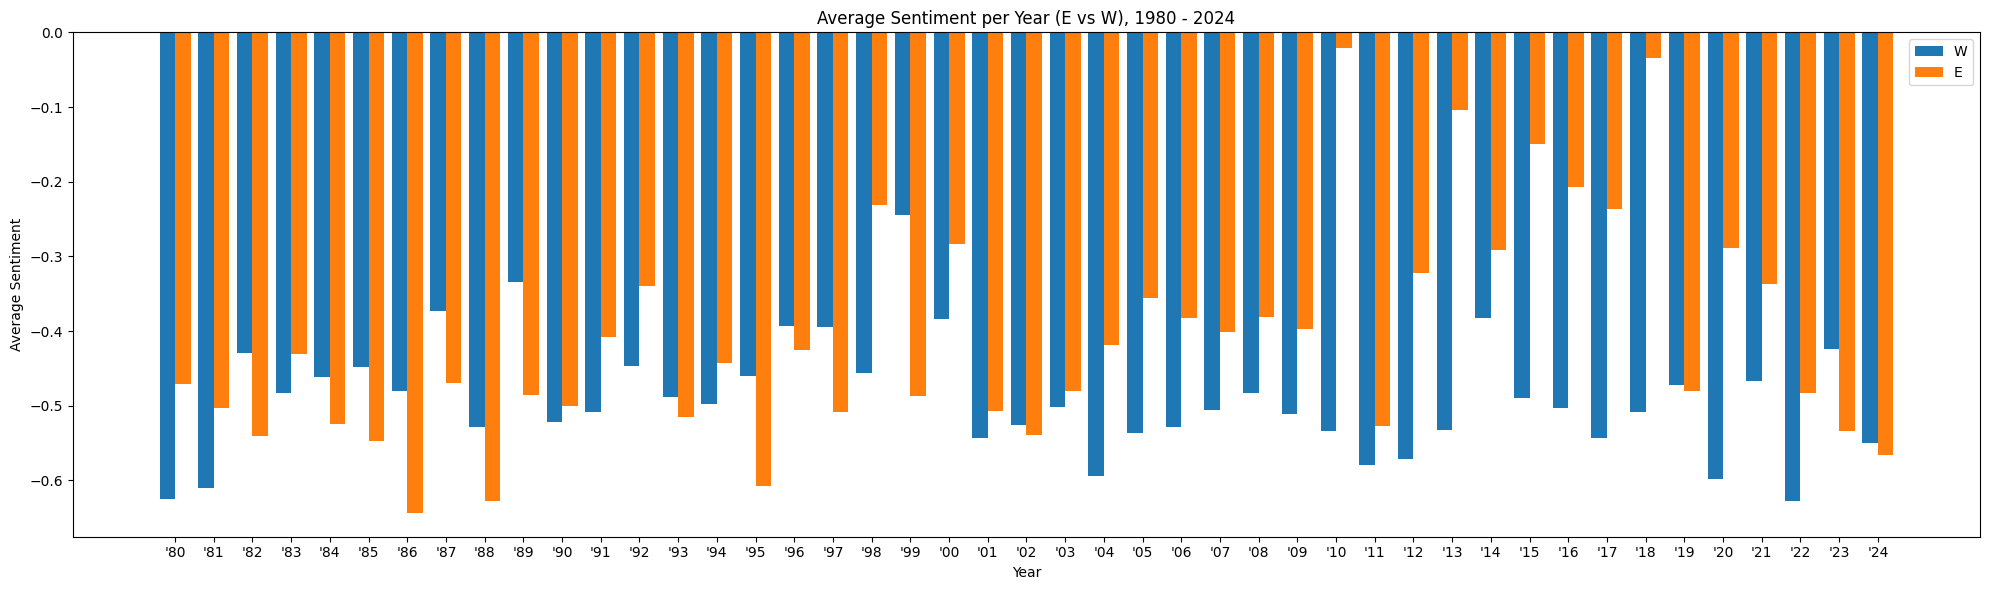

In [13]:
print("Generating yearly sentiment visualization...\n")
%run visualize_main_yearly.py

### Quarterly Sentiment Trends

**What it does**:
- Calculates average sentiment per quarter for each category
- Creates higher-resolution temporal view than yearly analysis
- Useful for identifying short-term sentiment shifts

**Output**: `sentiment_main_quarterly.png` (quarterly trend visualization)

Generating quarterly sentiment visualization...



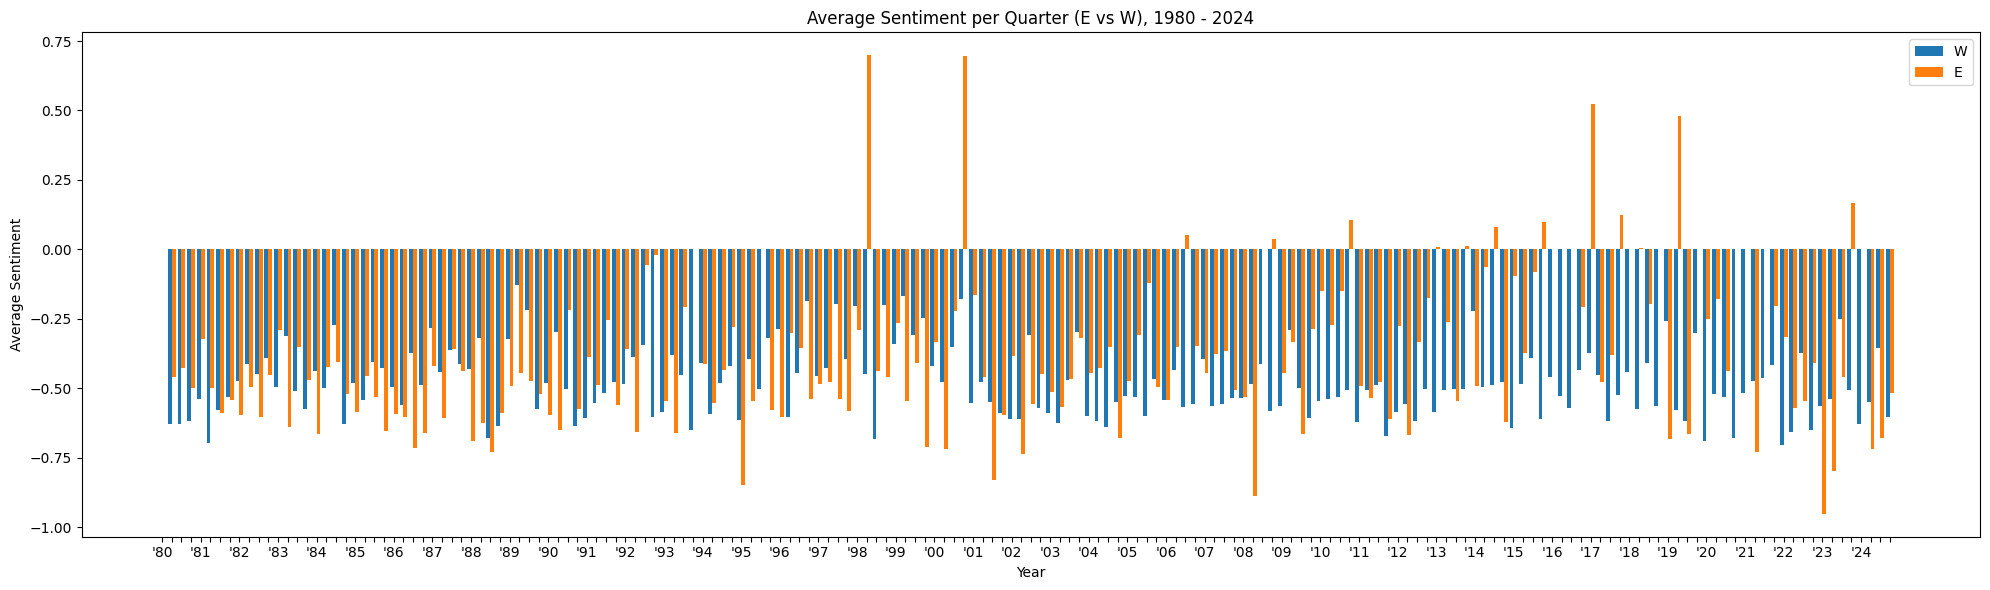

In [14]:
print("Generating quarterly sentiment visualization...\n")
%run visualize_main_quarterly.py

## Step 7: Analyze Sentiment by Category

Examine sentiment distribution across article categories (Energy vs Weapons).

### Calculate Sentiment Category Counts

**What it does**:
- Applies threshold-based classification to continuous polarity scores:
  - `score > 0.25` → positive
  - `score < -0.25` → negative
  - `-0.25 ≤ score ≤ 0.25` → neutral
- Counts sentiment categories (positive/neutral/negative) for each article category (E/W/SPLIT)
- Generates cross-tabulation of article category × sentiment category

In [15]:
print("Calculating sentiment category distributions...\n")
%run sentiment_calculations.py

Calculating sentiment category distributions...

sentiment_category  negative  neutral  positive
Category                                       
E                        909      160       105
SPLIT                     85       10         3
W                       2175      405       123


### Visualize Sentiment by Category

**What it does**:
- Creates visualizations comparing sentiment across categories
- May include boxplots, bar charts, or other categorical comparisons
- Highlights differences in sentiment between Energy and Weapons discourse

**Output**: Visualization files showing sentiment distribution by category

Generating category-based sentiment visualizations...



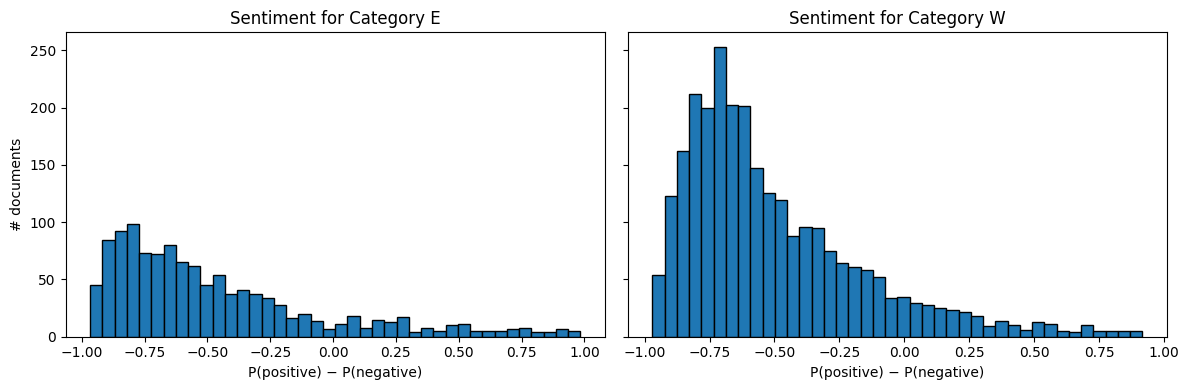

Loaded everything from sentence_sentiment_with_meta.csv
Saved plots to sentiment_E_W.png


In [16]:
print("Generating category-based sentiment visualizations...\n")
%run visualize_sentiment_categories.py